                                             Лабораторна робота №2 “Пошук асоціативних правил”
                                                    Виконала Доля Анастасія КН-42

Мета: ознайомитися з принципами побудови асоціативних правил (association rule mining) на реальних даних користувацьких уподобань. Навчитись виконувати пошук частих наборів елементів (frequent itemsets) і формувати асоціативні правила за допомогою метрик support, confidence і lift на основі набору даних MovieLens Small. Розвинути навички попередньої обробки даних, перетворення даних у транзакційний формат і інтерпретації результатів.


In [ ]:
##
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
from mlxtend.frequent_patterns import apriori, association_rules

In [43]:
DATA_DIR = r'C:\2kurs\lads iad\ml-latest-small'

ratings = pd.read_csv(f'{DATA_DIR}/ratings.csv')
movies  = pd.read_csv(f'{DATA_DIR}/movies.csv')

print('ratings.csv:')
print(f'\nsize: {ratings.shape}\n')

print('movies.csv:')
print(f'\nsize: {movies.shape}')

ratings.csv:

size: (100836, 4)

movies.csv:

size: (9742, 3)


In [44]:
#merging tables (movieId)
df = ratings.merge(movies, on='movieId')
print('Merged DataFrame:')
print(df.head())
print(f'\nsize: {df.shape}\n')


Merged DataFrame:
   userId  movieId  rating  timestamp                        title  \
0       1        1     4.0  964982703             Toy Story (1995)   
1       1        3     4.0  964981247      Grumpier Old Men (1995)   
2       1        6     4.0  964982224                  Heat (1995)   
3       1       47     5.0  964983815  Seven (a.k.a. Se7en) (1995)   
4       1       50     5.0  964982931   Usual Suspects, The (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                               Comedy|Romance  
2                        Action|Crime|Thriller  
3                             Mystery|Thriller  
4                       Crime|Mystery|Thriller  

size: (100836, 6)



Завантажено два датасети: ratings.csv (100836 записів) та movies.csv (9742 фільми), після чого виконано їх об’єднання за ключем movieId.

In [45]:
#d) rating>=4.0
df_highRatings = df[df['rating'] >= 4.0][['userId', 'title']]
print(f'Total rows before filtering: {len(df):>7}')
print(f'Rows with ratings >= 4.0: {len(df_highRatings):>7}')
print("Unique movies:", df_highRatings['title'].nunique())
print (f"Unique users: {df_highRatings['userId'].nunique()}")
print(f'% of high ratings: {len(df_highRatings) / len(df) * 100:.2f}%')

Total rows before filtering:  100836
Rows with ratings >= 4.0:   48580
Unique movies: 6297
Unique users: 609
% of high ratings: 48.18%


Застосовано фільтрацію rating ≥ 4.0, яка фактично трансформує задачу у бінарну: фільм або входить до множини вподобань користувача, або ні.
Таким чином, кожен користувач починає розглядатися як транзакція, що містить набір фільмів, які йому сподобались.

In [46]:
#2
#a)matrix of users and movies
matrix = df_highRatings.assign(value=1).pivot_table(
    index='userId', 
    columns='title', 
    values='value',
    fill_value=0)

matrix = matrix.astype(bool)

print(f'Size of the user-movie matrix: {matrix.shape}')
print(f'rows/users: {matrix.shape[0]}, columns/movies: {matrix.shape[1]}')
print(matrix.head())


Size of the user-movie matrix: (609, 6297)
rows/users: 609, columns/movies: 6297
title   '71 (2014)  'Hellboy': The Seeds of Creation (2004)  \
userId                                                        
1            False                                    False   
2            False                                    False   
3            False                                    False   
4            False                                    False   
5            False                                    False   

title   'Salem's Lot (2004)  'Til There Was You (1997)  'burbs, The (1989)  \
userId                                                                       
1                     False                      False               False   
2                     False                      False               False   
3                     False                      False               False   
4                     False                      False               False   
5        

Побудована матриця “користувач–фільм” відображає структуру взаємодії користувачів з контентом: кожен рядок — це конкретний користувач, а кожен стовпець — окремий фільм. Значення True означає наявність інтересу.

Важливо, що отримана матриця є сильно розрідженою: більшість користувачів взаємодіють лише з невеликою частиною всіх доступних фільмів. Саме така структура даних і визначає подальшу поведінку алгоритму — часті набори формуються переважно навколо популярних об’єктів.

In [47]:
#3
support_values = [0.05, 0.1, 0.3]

print("Кількість частих наборів при різних значеннях min_support:")
for s in support_values:
    itemsets_temp = apriori(matrix, min_support=s, use_colnames=True)
    print(f"min_support = {s}: {len(itemsets_temp)} наборів")

Кількість частих наборів при різних значеннях min_support:
min_support = 0.05: 33189 наборів
min_support = 0.1: 863 наборів
min_support = 0.3: 6 наборів


Перевірено три значення параметра min_support: 0.05, 0.1 і 0.3. 
min_support = 0.05 — набір має зустрічатися щонайменше у 5% користувачів;
min_support = 0.1 — щонайменше у 10% користувачів;
min_support = 0.3 — щонайменше у 30% користувачів.

Оскільки після фільтрації в наборі залишилось 609 користувачів, то це приблизно відповідає таким мінімальним порогам:
0.05 → близько 30 користувачів;
0.1 → близько 61 користувач;
0.3 → близько 183 користувачів.

Отримані результати показали дуже сильну залежність кількості знайдених наборів від значення support:
при min_support = 0.05 знайдено 33189 наборів;
при min_support = 0.1 — 863 набори;
при min_support = 0.3 — лише 6 наборів.

Така різниця є закономірною. При малому порозі 0.05 алгоритм враховує навіть відносно рідкісні поєднання, тому кількість знайдених комбінацій різко зростає. При підвищенні порогу до 0.1 значна частина менш стійких наборів автоматично відсікається. А при 0.3 залишаються лише наймасовіші та найочевидніші зв’язки, тобто фактично тільки найпопулярніші фільми та їх найстійкіші поєднання.

In [48]:
frequent_itemsets = apriori(matrix, min_support=0.05, use_colnames=True)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)

print('Кількість знайдених частих наборів:', len(frequent_itemsets))
frequent_itemsets.head()

Кількість знайдених частих наборів: 33189


,support,itemsets,length
0,0.080460,frozenset({12 Angry Men (1957)}),1
1,0.124795,frozenset({2001: A Space Odyssey (1968)}),1
2,0.065681,frozenset({28 Days Later (2002)}),1
3,0.062397,frozenset({300 (2007)}),1
4,0.057471,"frozenset({40-Year-Old Virgin, The (2005)})",1


In [49]:
top_itemsets = frequent_itemsets.sort_values(by='support', ascending=False).head(10)
print("Топ-10 частих наборів за support:")
print(top_itemsets[['support', 'itemsets', 'length']].to_string(index=False))

Топ-10 частих наборів за support:
 support                                                           itemsets  length
0.449918                      frozenset({Shawshank Redemption, The (1994)})       1
0.408867                                   frozenset({Forrest Gump (1994)})       1
0.400657                                   frozenset({Pulp Fiction (1994)})       1
0.369458                      frozenset({Silence of the Lambs, The (1991)})       1
0.364532                                    frozenset({Matrix, The (1999)})       1
0.330049             frozenset({Star Wars: Episode IV - A New Hope (1977)})       1
0.293924                                     frozenset({Fight Club (1999)})       1
0.287356                               frozenset({Schindler's List (1993)})       1
0.275862 frozenset({Shawshank Redemption, The (1994), Forrest Gump (1994)})       2
0.275862 frozenset({Star Wars: Episode V - The Empire Strikes Back (1980)})       1


In [50]:
frequent_combinations = frequent_itemsets[frequent_itemsets['length'] >= 2] \
    .sort_values(by='support', ascending=False)

print("\nФільми, які найчастіше зустрічаються разом:")
print(frequent_combinations[['support', 'itemsets', 'length']].head(10).to_string(index=False))


Фільми, які найчастіше зустрічаються разом:
 support                                                                                                      itemsets  length
0.275862                                            frozenset({Shawshank Redemption, The (1994), Forrest Gump (1994)})       2
0.259442                                            frozenset({Pulp Fiction (1994), Shawshank Redemption, The (1994)})       2
0.249589                                            frozenset({Pulp Fiction (1994), Silence of the Lambs, The (1991)})       2
0.236453 frozenset({Star Wars: Episode V - The Empire Strikes Back (1980), Star Wars: Episode IV - A New Hope (1977)})       2
0.229885                               frozenset({Shawshank Redemption, The (1994), Silence of the Lambs, The (1991)})       2
0.223317                                                         frozenset({Pulp Fiction (1994), Forrest Gump (1994)})       2
0.211823                                        frozenset({Schindl

Для аналізу обрали min_support = 0.05. Такий поріг дозволяє не втратити цікаві асоціації між фільмами і дає достатньо матеріалу для подальшого побудування правил, але є і зворотний бік: кількість частих наборів стає дуже великою, а отже серед них зростає частка тривіальних або менш інформативних поєднань. Саме тому цей поріг добре підходить для дослідження структури даних, але потребує подальшої фільтрації на етапі побудови асоціативних правил.

Якщо подивитися на топ-набори за support, то серед них переважають дуже відомі фільми, такі як The Shawshank Redemption, Forrest Gump, Pulp Fiction, The Silence of the Lambs, The Matrix. Це означає, що часті набори у значній мірі формуються навколо популярного кіно, яке позитивно оцінює велика кількість користувачів. Серед комбінацій із двох фільмів найчастіше разом зустрічаються The Shawshank Redemption і Forrest Gump із support 0.275862, тобто майже у 27.6% користувачів ці два фільми одночасно входять до множини позитивно оцінених.

In [51]:
#4
min_confidence = 0.6

rules = association_rules(
    frequent_itemsets_rules,
    metric="confidence",
    min_threshold=min_confidence
)

rules = rules[rules['lift'] > 1].copy()

print(f"Кількість знайдених правил після фільтрації: {len(rules)}")

Кількість знайдених правил після фільтрації: 153038


На даному етапі на основі знайдених частих наборів було сформовано асоціативні правила, які описують залежності між вподобаннями користувачів.

Для генерації правил використовується параметр min_confidence, який визначає мінімальну умовну ймовірність того, що при наявності набору A користувач також обере набір B.

У роботі було обрано значення min_confidence = 0.6. Це означає, що правило враховується лише тоді, коли у щонайменше 60% випадків наявність антецедента (A) супроводжується появою консеквента (B).

Додатково було застосовано фільтрацію за умовою lift > 1, що дозволяє залишити лише ті правила, де залежність між наборами є сильнішою за випадкову.

In [52]:
# в) Топ-10 за lift
top10_rules = rules.sort_values(by='lift', ascending=False).head(10)

print("Топ-10 правил за lift:")
print(top10_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].to_string(index=False))

Топ-10 правил за lift:
                                                                                                                                                antecedents                                                                                                                                                 consequents  support  confidence      lift
                                               frozenset({Kill Bill: Vol. 2 (2004), Matrix, The (1999), Star Wars: Episode VI - Return of the Jedi (1983)})                     frozenset({Star Wars: Episode V - The Empire Strikes Back (1980), Kill Bill: Vol. 1 (2003), Star Wars: Episode IV - A New Hope (1977)}) 0.052545    0.888889 13.203252
                    frozenset({Star Wars: Episode V - The Empire Strikes Back (1980), Kill Bill: Vol. 1 (2003), Star Wars: Episode IV - A New Hope (1977)})                                                frozenset({Kill Bill: Vol. 2 (2004), Matrix, The (1999), Star Wars: Episode VI - Return 

Для детального аналізу було відібрано правила з найбільшими значеннями lift.
У топ-правилах значення lift досягають ≈12–13, що означає, що спільна поява відповідних наборів фільмів у вподобаннях користувачів у понад 12 разів перевищує випадкову.
Це свідчить про наявність дуже сильних залежностей між певними групами фільмів (наприклад, франшизи або тематично схожі фільми).

In [53]:
# г) Інтерпретація топ-5 правил
print('Інтерпретація топ-5 правил за lift:\n')
for _, row in top10_rules.head(5).iterrows():
    ant = list(row['antecedents'])
    con = list(row['consequents'])
    
    print(f"Якщо користувачу сподобались: {ant}")
    print(f"то ймовірно йому сподобаються: {con}")
    print(f"Support = {row['support']:.3f}, Confidence = {row['confidence']:.3f}, Lift = {row['lift']:.3f}")
    print("---")

Інтерпретація топ-5 правил за lift:

Якщо користувачу сподобались: ['Kill Bill: Vol. 2 (2004)', 'Matrix, The (1999)', 'Star Wars: Episode VI - Return of the Jedi (1983)']
то ймовірно йому сподобаються: ['Star Wars: Episode V - The Empire Strikes Back (1980)', 'Kill Bill: Vol. 1 (2003)', 'Star Wars: Episode IV - A New Hope (1977)']
Support = 0.053, Confidence = 0.889, Lift = 13.203
---
Якщо користувачу сподобались: ['Star Wars: Episode V - The Empire Strikes Back (1980)', 'Kill Bill: Vol. 1 (2003)', 'Star Wars: Episode IV - A New Hope (1977)']
то ймовірно йому сподобаються: ['Kill Bill: Vol. 2 (2004)', 'Matrix, The (1999)', 'Star Wars: Episode VI - Return of the Jedi (1983)']
Support = 0.053, Confidence = 0.780, Lift = 13.203
---
Якщо користувачу сподобались: ['Kill Bill: Vol. 2 (2004)', 'Matrix, The (1999)', 'Star Wars: Episode V - The Empire Strikes Back (1980)', 'Star Wars: Episode IV - A New Hope (1977)']
то ймовірно йому сподобаються: ['Kill Bill: Vol. 1 (2003)', 'Star Wars: Episod

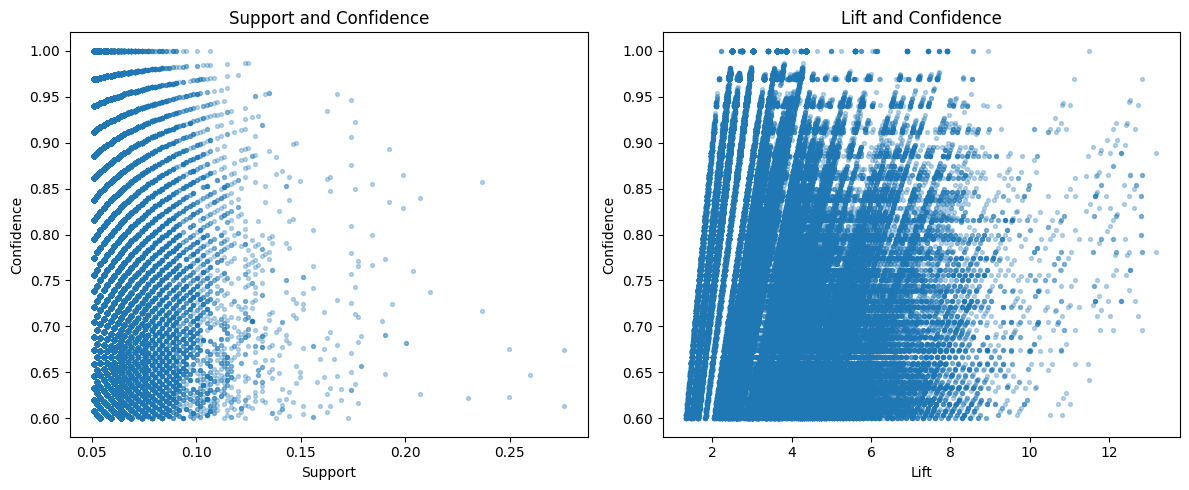

In [54]:
# е) Графіки 
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(rules['support'], rules['confidence'], alpha=0.3, s=8)
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.title('Support and Confidence')

plt.subplot(1, 2, 2)
plt.scatter(rules['lift'], rules['confidence'], alpha=0.3, s=8)
plt.xlabel('Lift')
plt.ylabel('Confidence')
plt.title('Lift and Confidence')

plt.tight_layout()
plt.show()

Побудовані діаграми розсіювання дозволяють оцінити розподіл правил за основними метриками.

На графіку support–confidence видно, що більшість правил мають невеликий support і середній або високий confidence. Це означає, що багато правил базуються на відносно рідкісних комбінаціях, але при цьому є стабільними.

На графіку lift–confidence спостерігається концентрація правил у зоні невеликих значень lift, тоді як лише незначна частина має високі значення. Саме ці правила є найбільш цікавими з точки зору рекомендацій.

In [ ]:
confidence_values = [0.3, 0.5, 0.6, 0.7, 0.8]

for conf in confidence_values:
    temp_rules = association_rules(
        frequent_itemsets,
        metric="confidence",
        min_threshold=conf
    )
    temp_rules = temp_rules[temp_rules["lift"] > 1]
    print(f"min_confidence = {conf}: кількість правил = {len(temp_rules)}")

min_confidence = 0.3: кількість правил = 360464
min_confidence = 0.5: кількість правил = 219965
min_confidence = 0.6: кількість правил = 153038
min_confidence = 0.7: кількість правил = 97697
min_confidence = 0.8: кількість правил = 49889


Для дослідження впливу параметра min_confidence було розглянуто декілька значень. Зі збільшенням значення confidence кількість правил поступово зменшується. Це пояснюється тим, що підвищення порогу відсікає залежності, які не є достатньо стабільними.

ВИСНОВОК

У ході виконання лабораторної роботи було реалізовано повний цикл побудови асоціативних правил на основі реальних даних користувацьких уподобань (MovieLens). Дані було підготовлено, перетворено у транзакційний формат і використано як вхід для алгоритму Apriori.

У процесі аналізу було встановлено, що параметр min_support має критичний вплив на кількість частих наборів. Зменшення цього параметра до 0.05 дозволило отримати повну картину залежностей, однак призвело до значного збільшення обсягу результатів. При підвищенні до 0.1 і 0.3 кількість наборів різко зменшується (до 863 і 6 відповідно), що підтверджує високу чутливість алгоритму до цього параметра.

Подальше формування асоціативних правил показало, що параметр min_confidence визначає їхню надійність. При значенні 0.6 було отримано 153038 правил після фільтрації за lift > 1, що свідчить про наявність великої кількості залежностей у даних. Експеримент із різними значеннями confidence показав, що зменшення порогу значно збільшує кількість правил (до 360464 при 0.3), але знижує їхню якість, тоді як підвищення призводить до більш строгого, але обмеженого набору результатів.

Аналіз топ-правил за метрикою lift продемонстрував наявність сильних взаємозв’язків між окремими групами фільмів, де значення lift досягають понад 12, що значно перевищує випадкову ймовірність.

Побудовані графіки підтвердили, що більшість правил має невеликий support і середній або високий confidence, тоді як лише незначна частина демонструє високі значення lift.

Таким чином, у роботі було показано, що ефективність асоціативного аналізу значною мірою залежить від вибору параметрів. Отримані результати підтверджують, що асоціативні правила можуть бути ефективно використані в рекомендаційних системах, однак потребують додаткової фільтрації та інтерпретації для практичного застосування.